In [39]:
from utils.dynamicRieszFunctions import estimateDynamicRiesz_all
from utils.dynamicRieszFunctions import estimateDynamicRiesz
import torch
import pandas as pd
import time
from torch.distributions import Normal
from utils.dgp import DiD_DGP
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Settings


In [17]:
lasso_cv_settings = {
    'b_degree' : 1,
    'cv_folds' : 5,
    'random_state' : 42
}

lasso_a_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' : "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

lasso_f_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' :  "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

rf_a_settings = {
    'poly_degree' : 0,
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' : -1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}
rf_f_settings = {
    'poly_degree' : 1, # 1 or 2?
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' : -1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}

net_a_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}

net_f_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}


## Coefficients and Parameters

In [27]:
# Parameters
N = 1000
tmax = 40
dimX = 3
dimZ = 2
seed = 123
folds = 10

## Propensity models 

In [28]:
# Bounds (only for truncated distributions)
lower = 0.30
upper = 0.70

# Define logistic function
def logistic(x):
    return torch.exp(x) / (1 + torch.exp(x))

# Define a truncated logistic function
def truncated_logistic(x):
    return lower + (upper - lower) * logistic(x)

# Simple nonlinear probability (from adversarial Riesz paper)
def truncated_adv(x):
    return lower + (upper - lower) * (x > 0)


## Generate data

In [29]:
dgp = DiD_DGP(dim_X=dimX, dim_Z=dimZ, 
                alpha_1 = .5, # Y_1s effect on D
              gamma_1=torch.ones(dimZ), # Z effect on D
                gamma_2=torch.ones(dimZ), # Z effect on Y
                g = truncated_adv # specification of the propensity modek
                )

data = dgp.generate(n =N*tmax, seed = seed)
X1 = data['X1']
X2 = data['X2']
Y1 = data['Y1']
Y2 = data['Y2']
Z = data['Z']
D = data['D']


In [30]:
ATT_calculations = dgp.simulate_ATT(n = 100000000)


In [31]:
ATT_calculations["ATT"]

tensor(1.9753)

In [32]:
print(X1.shape)
print(X2.shape)
print(Y1.shape)
print(Y2.shape)
print(Z.shape)
print(D.shape)

torch.Size([40000, 3])
torch.Size([40000, 3])
torch.Size([40000])
torch.Size([40000])
torch.Size([40000, 2])
torch.Size([40000])


In [33]:
print(D.mean())

tensor(0.5225)


In [34]:
# Naive ATT estimate
Y2[D==1].mean() - Y2[D==0].mean()

tensor(3.6360)

## Estimation

In [35]:
time0 = time.time()
pred_theta = torch.zeros(tmax,18)
pred_sig = torch.zeros(tmax,18)

RR1 = torch.zeros(N,tmax,18)
RR2 = torch.zeros(N,tmax,18)
f1 = torch.zeros(N,tmax,18)
f2 = torch.zeros(N,tmax,18)

for t in tqdm(range(0,tmax)):

    # Get data for current iteration
    X1_sub = X1[t*N:(t+1)*N,:]
    X2_sub = X2[t*N:(t+1)*N,:]
    Y1_sub = Y1[t*N:(t+1)*N].view(-1, 1)
    Y2_sub = Y2[t*N:(t+1)*N].view(-1, 1)
    D_sub = D[t*N:(t+1)*N].view(-1, 1)
    Z_sub = Z[t*N:(t+1)*N,:]




    pred_theta[t,3], pred_sig[t,3], RR1[:,t,3:4], RR2[:,t,3:4] = estimateDynamicRiesz(Y1_sub, Y2_sub, D_sub, Z_sub, X1_sub  , X2_sub, folds,
                                                                     method_a = "RF", rf_a_settings=rf_a_settings,
                                                                        method_f = "RF", rf_f_settings = rf_f_settings)





100%|██████████| 40/40 [04:44<00:00,  7.11s/it]


In [36]:
pred_theta[:,3] 

tensor([1.9788, 2.0169, 1.9107, 2.0327, 1.9792, 1.8991, 1.9542, 1.9726, 1.8580,
        2.0898, 1.9011, 2.1306, 1.9342, 2.0641, 1.9491, 2.0634, 1.9170, 1.9917,
        1.8609, 1.9632, 2.0958, 1.8938, 1.9010, 2.0447, 2.0874, 1.9836, 1.9766,
        2.1058, 1.9950, 1.9155, 2.0133, 1.9396, 1.9709, 1.9868, 1.9634, 1.9882,
        2.0621, 2.0102, 1.8671, 1.9686])

In [37]:
torch.mean(pred_theta[:,3] - ATT_calculations["ATT"]) # bias

tensor(0.0056)

[]

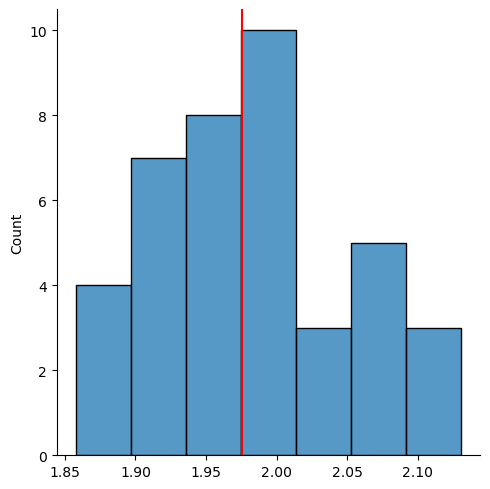

In [52]:
sns.displot(pred_theta[:,3] )
plt.axvline(x = ATT_calculations["ATT"], c = "red" )
plt.plot()

## Application

In [ ]:
from utils.application import *#
data_apllication = application_data()

In [ ]:
data_dict = data_apllication.get_data(2003, 2004 )

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


In [ ]:
X1 = data_dict['X1']
X2 = data_dict['X2']
Y1 = data_dict['Y1']
Y2 = data_dict['Y2']
D = data_dict['D']
Z = data_dict['Z']  

In [ ]:
D.sum()

tensor(102.)

In [ ]:
X1.shape

torch.Size([2491, 5])

In [ ]:
estimateDynamicRiesz(Y1, Y2, D, Z, X1, X2, folds,
                                                                     method_a = "RF", rf_a_settings=rf_a_settings,
                                                                        method_f = "RF", rf_f_settings = rf_f_settings)

(tensor(-0.0089),
 tensor(0.7505),
 tensor([[1.0691],
         [1.0460],
         [1.0492],
         ...,
         [1.0429],
         [1.0494],
         [1.0671]]),
 tensor([[1.0561],
         [1.0377],
         [1.0472],
         ...,
         [1.0393],
         [1.0427],
         [1.0567]]))

In [ ]:
test =pd.read_csv("https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/minwage_data.csv", index_col=0)

In [ ]:
Z = test[test["year"] == 2003][["region", "censusdiv"]].reset_index(drop=True)

test["region"].value_counts()

region
3    7469
2    7301
4    2730
1    1351
Name: count, dtype: int64

In [ ]:
Z["region"].value_counts()

region
3    1067
2    1043
4     390
1     193
Name: count, dtype: int64

In [ ]:
Z["censusdiv"].value_counts()

censusdiv
4    606
5    584
3    437
7    388
8    234
9    156
2    150
6     95
1     43
Name: count, dtype: int64